# Import All Libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [58]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Dataset

In [59]:
df = pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')

In [60]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Data Cleaning & Preprocessing

In [61]:
df.shape

(5110, 12)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [63]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [64]:
# checking missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [65]:
# filling Missing values
df['bmi']=df['bmi'].fillna(df['bmi'].mean())

In [66]:
# checking again missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [67]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [68]:
# drop duplicates values
df.drop_duplicates(inplace=True)

# Remove Unnecessary Column

In [69]:
df.drop(columns='id',axis=1,inplace=True)

In [70]:
df.gender.value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [71]:
# married value_count
df.ever_married.value_counts()

,count
ever_married,
Yes,3353
No,1757


In [72]:
# work_type value_count
df.work_type.value_counts()

,count
work_type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [73]:
# residence type value_count
df.Residence_type.value_counts()

,count
Residence_type,
Urban,2596
Rural,2514


In [74]:
# smoker value_count
df.smoking_status.value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [75]:
# Stroke value_count
df.stroke.value_counts()

,count
stroke,
0,4861
1,249


# Visualization

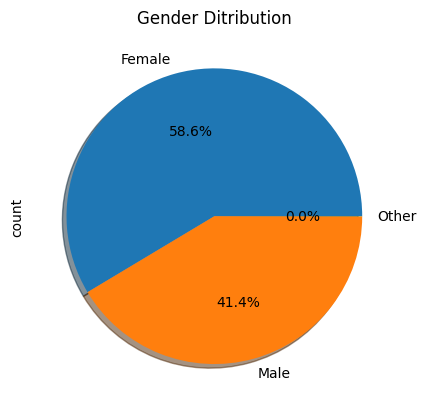

In [76]:
df.gender.value_counts().plot(kind='pie',autopct='%0.1f%%',shadow=True)
plt.title('Gender Ditribution')
plt.show()

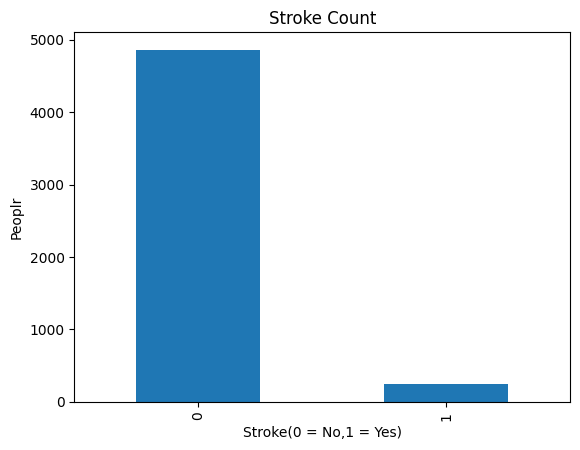

In [77]:
df.stroke.value_counts().plot(kind='bar')
plt.title('Stroke Count')
plt.xlabel('Stroke(0 = No,1 = Yes)')
plt.ylabel('Peoplr')
plt.show()

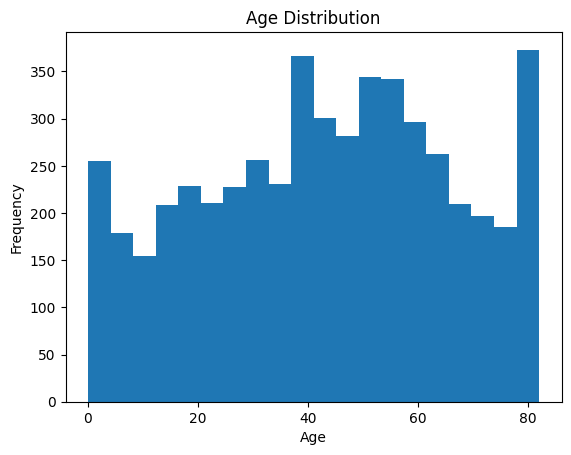

In [78]:
plt.hist(df['age'],bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

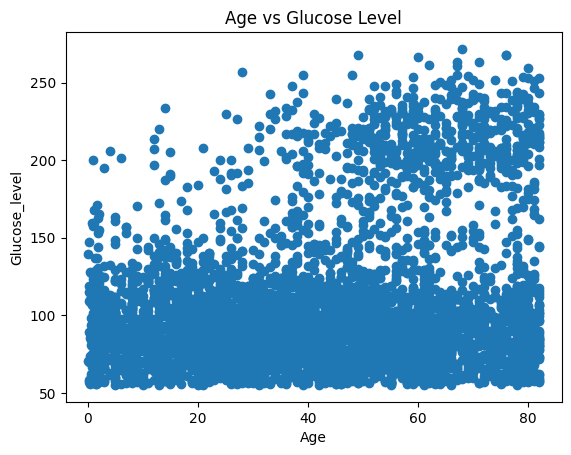

In [79]:
plt.scatter(df['age'],df['avg_glucose_level'])
plt.title('Age vs Glucose Level')
plt.xlabel('Age')
plt.ylabel('Glucose_level')
plt.show()

# Data Encoding

In [80]:
categorical_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']

In [81]:
# Initialize onehotencoder with sparse_output=False
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first')

In [82]:
# fit and transform the categorical columns
encoded_features=ohe.fit_transform(df[categorical_cols])

In [83]:
encoded_features

array([[1., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [84]:
ohe.get_feature_names_out()

array(['gender_Male', 'gender_Other', 'ever_married_Yes',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype=object)

In [85]:
# create a dataframe from the encoded features with their columns names
encoded_df = pd.DataFrame(encoded_features,columns=ohe.get_feature_names_out(categorical_cols),index=df.index)
encoded_df

,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5105,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5106,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5107,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [86]:
# drop the orginal categorical columns from the main DataFrame
df_processed=df.drop(columns=categorical_cols)
df_processed

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.600000,1
1,61.0,0,0,202.21,28.893237,1
2,80.0,0,1,105.92,32.500000,1
3,49.0,0,0,171.23,34.400000,1
4,79.0,1,0,174.12,24.000000,1
...,...,...,...,...,...,...
5105,80.0,1,0,83.75,28.893237,0
5106,81.0,0,0,125.20,40.000000,0
5107,35.0,0,0,82.99,30.600000,0
5108,51.0,0,0,166.29,25.600000,0


In [87]:
# Concatenate the process Dataframe with the new one hot encode DataFrame
df=pd.concat([df_processed,encoded_df],axis=1)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.893237,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,105.92,32.500000,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0,0,171.23,34.400000,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,79.0,1,0,174.12,24.000000,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Data Separation

In [88]:
x = df.drop(columns='stroke',axis=1)
y = df['stroke']

# Applying StandardScaler

In [89]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

# Train-Test-Split

In [90]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [91]:
x_train.shape,x_test.shape

((4088, 16), (1022, 16))

In [92]:
x

array([[ 1.05143428, -0.32860186,  4.18503199, ...,  2.1849511 ,
        -0.7667743 , -0.42731326],
       [ 0.78607007, -0.32860186, -0.2389468 , ..., -0.45767615,
         1.30416474, -0.42731326],
       [ 1.62639008, -0.32860186,  4.18503199, ..., -0.45767615,
         1.30416474, -0.42731326],
       ...,
       [-0.36384151, -0.32860186, -0.2389468 , ..., -0.45767615,
         1.30416474, -0.42731326],
       [ 0.34379639, -0.32860186, -0.2389468 , ...,  2.1849511 ,
        -0.7667743 , -0.42731326],
       [ 0.03420481, -0.32860186, -0.2389468 , ..., -0.45767615,
        -0.7667743 , -0.42731326]])

In [93]:
y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
5105,0
5106,0
5107,0
5108,0


# Data Modeling With Architecture Neural Networks (ANN)

In [94]:
model=tf.keras.Sequential([
    # input layer
    tf.keras.layers.InputLayer(input_shape=x_train.shape[1:]),

    # hidden layers
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),

    # Output layer
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [95]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [97]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [100]:
history = model.fit(x_train,y_train,validation_split=0.2,epochs=50,batch_size=32,callbacks=[early_stop])

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9422 - loss: 0.2783 - val_accuracy: 0.9548 - val_loss: 0.1608
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1582 - val_accuracy: 0.9548 - val_loss: 0.1546
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9538 - loss: 0.1521 - val_accuracy: 0.9548 - val_loss: 0.1523
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1478 - val_accuracy: 0.9548 - val_loss: 0.1485
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1461 - val_accuracy: 0.9548 - val_loss: 0.1492
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1437 - val_accuracy: 0.9548 - val_loss: 0.1489
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1419 - val_accuracy: 0.9548 - val_loss: 0.1508
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1408 - val_accuracy: 0.

# Graph Representation Training Loss & Validation Loss

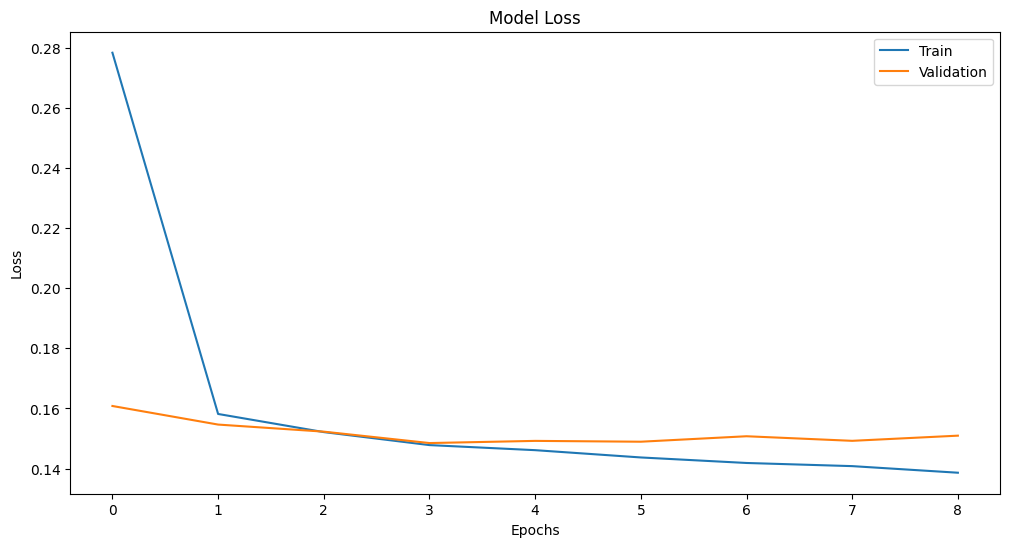

In [101]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

# Graph Representation Training Accuracy & Validation Accuracy

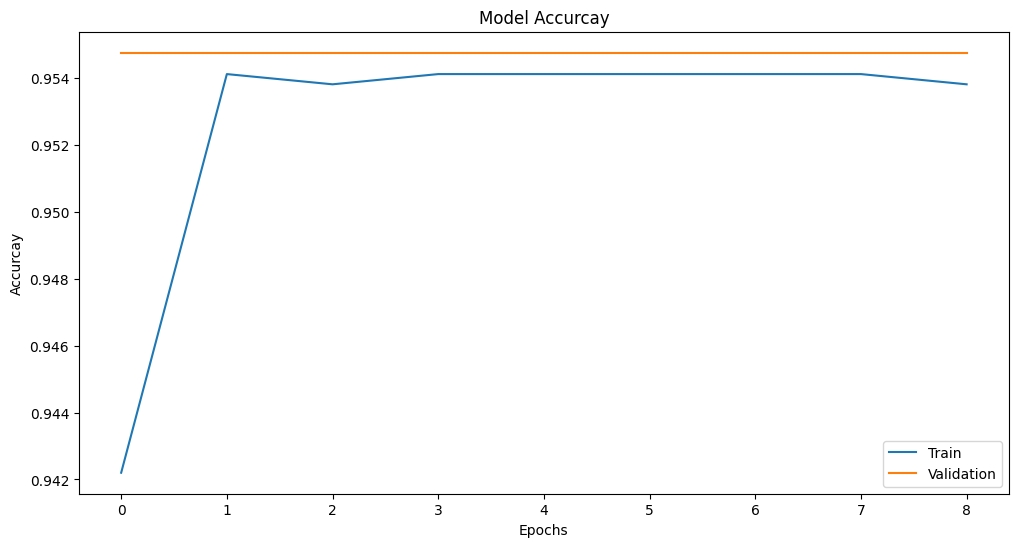

In [102]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accurcay')
plt.xlabel('Epochs')
plt.ylabel('Accurcay')
plt.legend(['Train','Validation'])
plt.show()

# Evaluation : Calculation of Test Loss & Accuracy

In [103]:
test_loss, test_accuracy =model.evaluate(x_test,y_test)
print(f'Test Loss: {test_loss}')
print(f'Test_Accuracy: {test_accuracy}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9393 - loss: 0.1834 
Test Loss: 0.18336611986160278
Test_Accuracy: 0.9393346309661865


# Metrics

In [117]:
y_pred = (model.predict(x_test) > 0.15).astype('int32')

print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))
print('F1:',f1_score(y_test,y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy: 0.9031311154598826
Precision: 0.2823529411764706
Recall: 0.3870967741935484
F1: 0.32653061224489793


# Real-Time Prediction

In [147]:
sample = x_test[0].reshape(1, -1)

prediction = model.predict(sample)

if prediction[0][0] > 0.5:
    print("predicted: Stroke Yes")
else:
    print("predicted: Stroke No")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
predicted: Stroke No
